# Exploratory Data Analysis (EDA)

## Questionnaire for Refugees and Host Community Members

Prepared by:
Yusuf Olatayo Kareem

Date:
July 2026

**Import Libraries**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", 100)

**Dataset Overview**

In [4]:
file = "sample_data/Questionnaire.xlsx"

df = pd.read_excel(file)

df.head()

,Timestamp,1. Age,2. Gender:,3. Nationality:,4. How long have you lived in Nigeria? (For Cameroonian refugees only),Ko5. How long have you been in this community since Cameroonians came (Nigerians only)?,\n6. What was the primary reason for leaving Cameroon?,7. Did you come to Nigeria alone or with family?,8. Do you feel safe in your current location?,9. Have you or someone you know experienced security threats or conflicts in Nigeria?,10. Have there been any reported incidents of crime or violence involving refugees and local communities?,11. How would you describe the relationship between Cameroonian refugees and Nigerians?,12. What are the major security concerns faced by Cameroonian refugees in Nigeria?,13. What are the major security concerns faced by Nigerians as a result of the presence of refugees? (Nigerians Only),"14. Are there opportunities for Cameroonian refugees to integrate into Nigerian society (e.g., work, education, social support)?",15.What support do you think the Nigerian government should provide to both refugees and host communities to improve security?,16. Do you have any recommendations on how to improve relations between Cameroonian refugees and Nigerians?
0,2026-01-28 16:49:02.649,B) 26-35,A) Male,A) Cameroonian,D) More than 6 years,6 years,B) Economic hardship,B) With family,B) No (If no explain below),A) Yes,A) Yes,B) Neutral,C) Economic exploitation,Constant stealing of farm produce by refugees,B) NO (If No select Other and explain),A) More security presence,I suggest join security operatives between host community and refugees
1,2026-01-28 17:04:44.374,B) 26-35,B) Female,A) Cameroonian,D) More than 6 years,About 7years,A) Conflict/Insecurity,B) With family,A) Yes,B) NO,B) No,B) Neutral,A) Harassment by security forces,None,B) NO (If No select Other and explain),B) Livelihood programs,Identity cards should be issued to reduce harassment by security forces and immigration officers
2,2026-01-28 17:19:31.528,B) 26-35,A) Male,A) Cameroonian,D) More than 6 years,7 years,A) Conflict/Insecurity,B) With family,A) Yes,B) NO,B) No,B) Neutral,A) Harassment by security forces,Increase in population of the country leading to the rapid consumption of available consumer goo...,A) Yes,B) Livelihood programs,I recommend Cameroonians(Refugees) be given political liberty since they are affected by governm...
3,2026-01-28 17:42:15.310,B) 26-35,A) Male,A) Cameroonian,D) More than 6 years,2018,A) Conflict/Insecurity,B) With family,B) No (If no explain below),A) Yes,A) Yes,C) Tense,B) Attacks by locals,Tense,A) Yes,B) Livelihood programs,The security post should be put in place around the closest host community because they are the ...
4,2026-01-28 18:43:01.506,D) 46-60,A) Male,A) Cameroonian,D) More than 6 years,I am Cameroonian refugee,C) Political persecution,B) With family,B) No (If no explain below),A) Yes,A) Yes,B) Neutral,"Besides Harrassment by security forces,we also have attacks on refugees and refugee communities ...",I am Cameroonian,The Nigerian Government besides opportunities for refugee integration should also without delay ...,A) More security presence,Yes. . Recommendations for Improving Relations Between Cameroonian Refugees and Host Communities...


**Dataset Overview**

In [5]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 185
Columns: 17


In [7]:
# Calculate missing values
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    "Column": df.columns,
    "Missing Count": missing_count.values,
    "Missing (%)": missing_percent.values
})


In [8]:
# Add a status column
missing_summary["Status"] = missing_summary["Missing (%)"].apply(
    lambda x: "✅ Complete" if x == 0 else
              "🟢 Low" if x < 5 else
              "🟡 Moderate" if x < 20 else
              "🔴 High"
)

# Sort by highest missing percentage
missing_summary = missing_summary.sort_values(
    by="Missing (%)",
    ascending=False
).reset_index(drop=True)


**Missing Value Summary**

In [9]:
display(missing_summary)

,Column,Missing Count,Missing (%),Status
0,13. What are the major security concerns faced by Nigerians as a result of the presence of refu...,119,64.32,🔴 High
1,Ko5. How long have you been in this community since Cameroonians came (Nigerians only)?,108,58.38,🔴 High
2,\n6. What was the primary reason for leaving Cameroon?,62,33.51,🔴 High
3,7. Did you come to Nigeria alone or with family?,61,32.97,🔴 High
4,4. How long have you lived in Nigeria? (For Cameroonian refugees only),61,32.97,🔴 High
5,9. Have you or someone you know experienced security threats or conflicts in Nigeria?,55,29.73,🔴 High
6,8. Do you feel safe in your current location?,42,22.70,🔴 High
7,12. What are the major security concerns faced by Cameroonian refugees in Nigeria?,41,22.16,🔴 High
8,16. Do you have any recommendations on how to improve relations between Cameroonian refugees and...,5,2.70,🟢 Low
9,Timestamp,0,0.00,✅ Complete


**Dataset Summary**

In [10]:
summary = pd.DataFrame({
    "Total Rows":[len(df)],
    "Total Columns":[df.shape[1]],
    "Duplicate Rows":[df.duplicated().sum()],
    "Columns with Missing":[sum(df.isnull().sum()>0)]
})

summary

,Total Rows,Total Columns,Duplicate Rows,Columns with Missing
0,185,17,0,9


**Variable Information**

In [11]:
info = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Non-null": df.count().values,
    "Unique Values": df.nunique().values
})

info

,Column,Data Type,Non-null,Unique Values
0,Timestamp,datetime64[ns],185,185
1,1. Age,object,185,5
2,2. Gender:,object,185,2
3,3. Nationality:,object,185,2
4,4. How long have you lived in Nigeria? (For Cameroonian refugees only),object,124,4
5,Ko5. How long have you been in this community since Cameroonians came (Nigerians only)?,object,77,32
6,\n6. What was the primary reason for leaving Cameroon?,object,123,4
7,7. Did you come to Nigeria alone or with family?,object,124,2
8,8. Do you feel safe in your current location?,object,143,35
9,9. Have you or someone you know experienced security threats or conflicts in Nigeria?,object,130,2


**Visualizations for Missing values**

<Axes: >

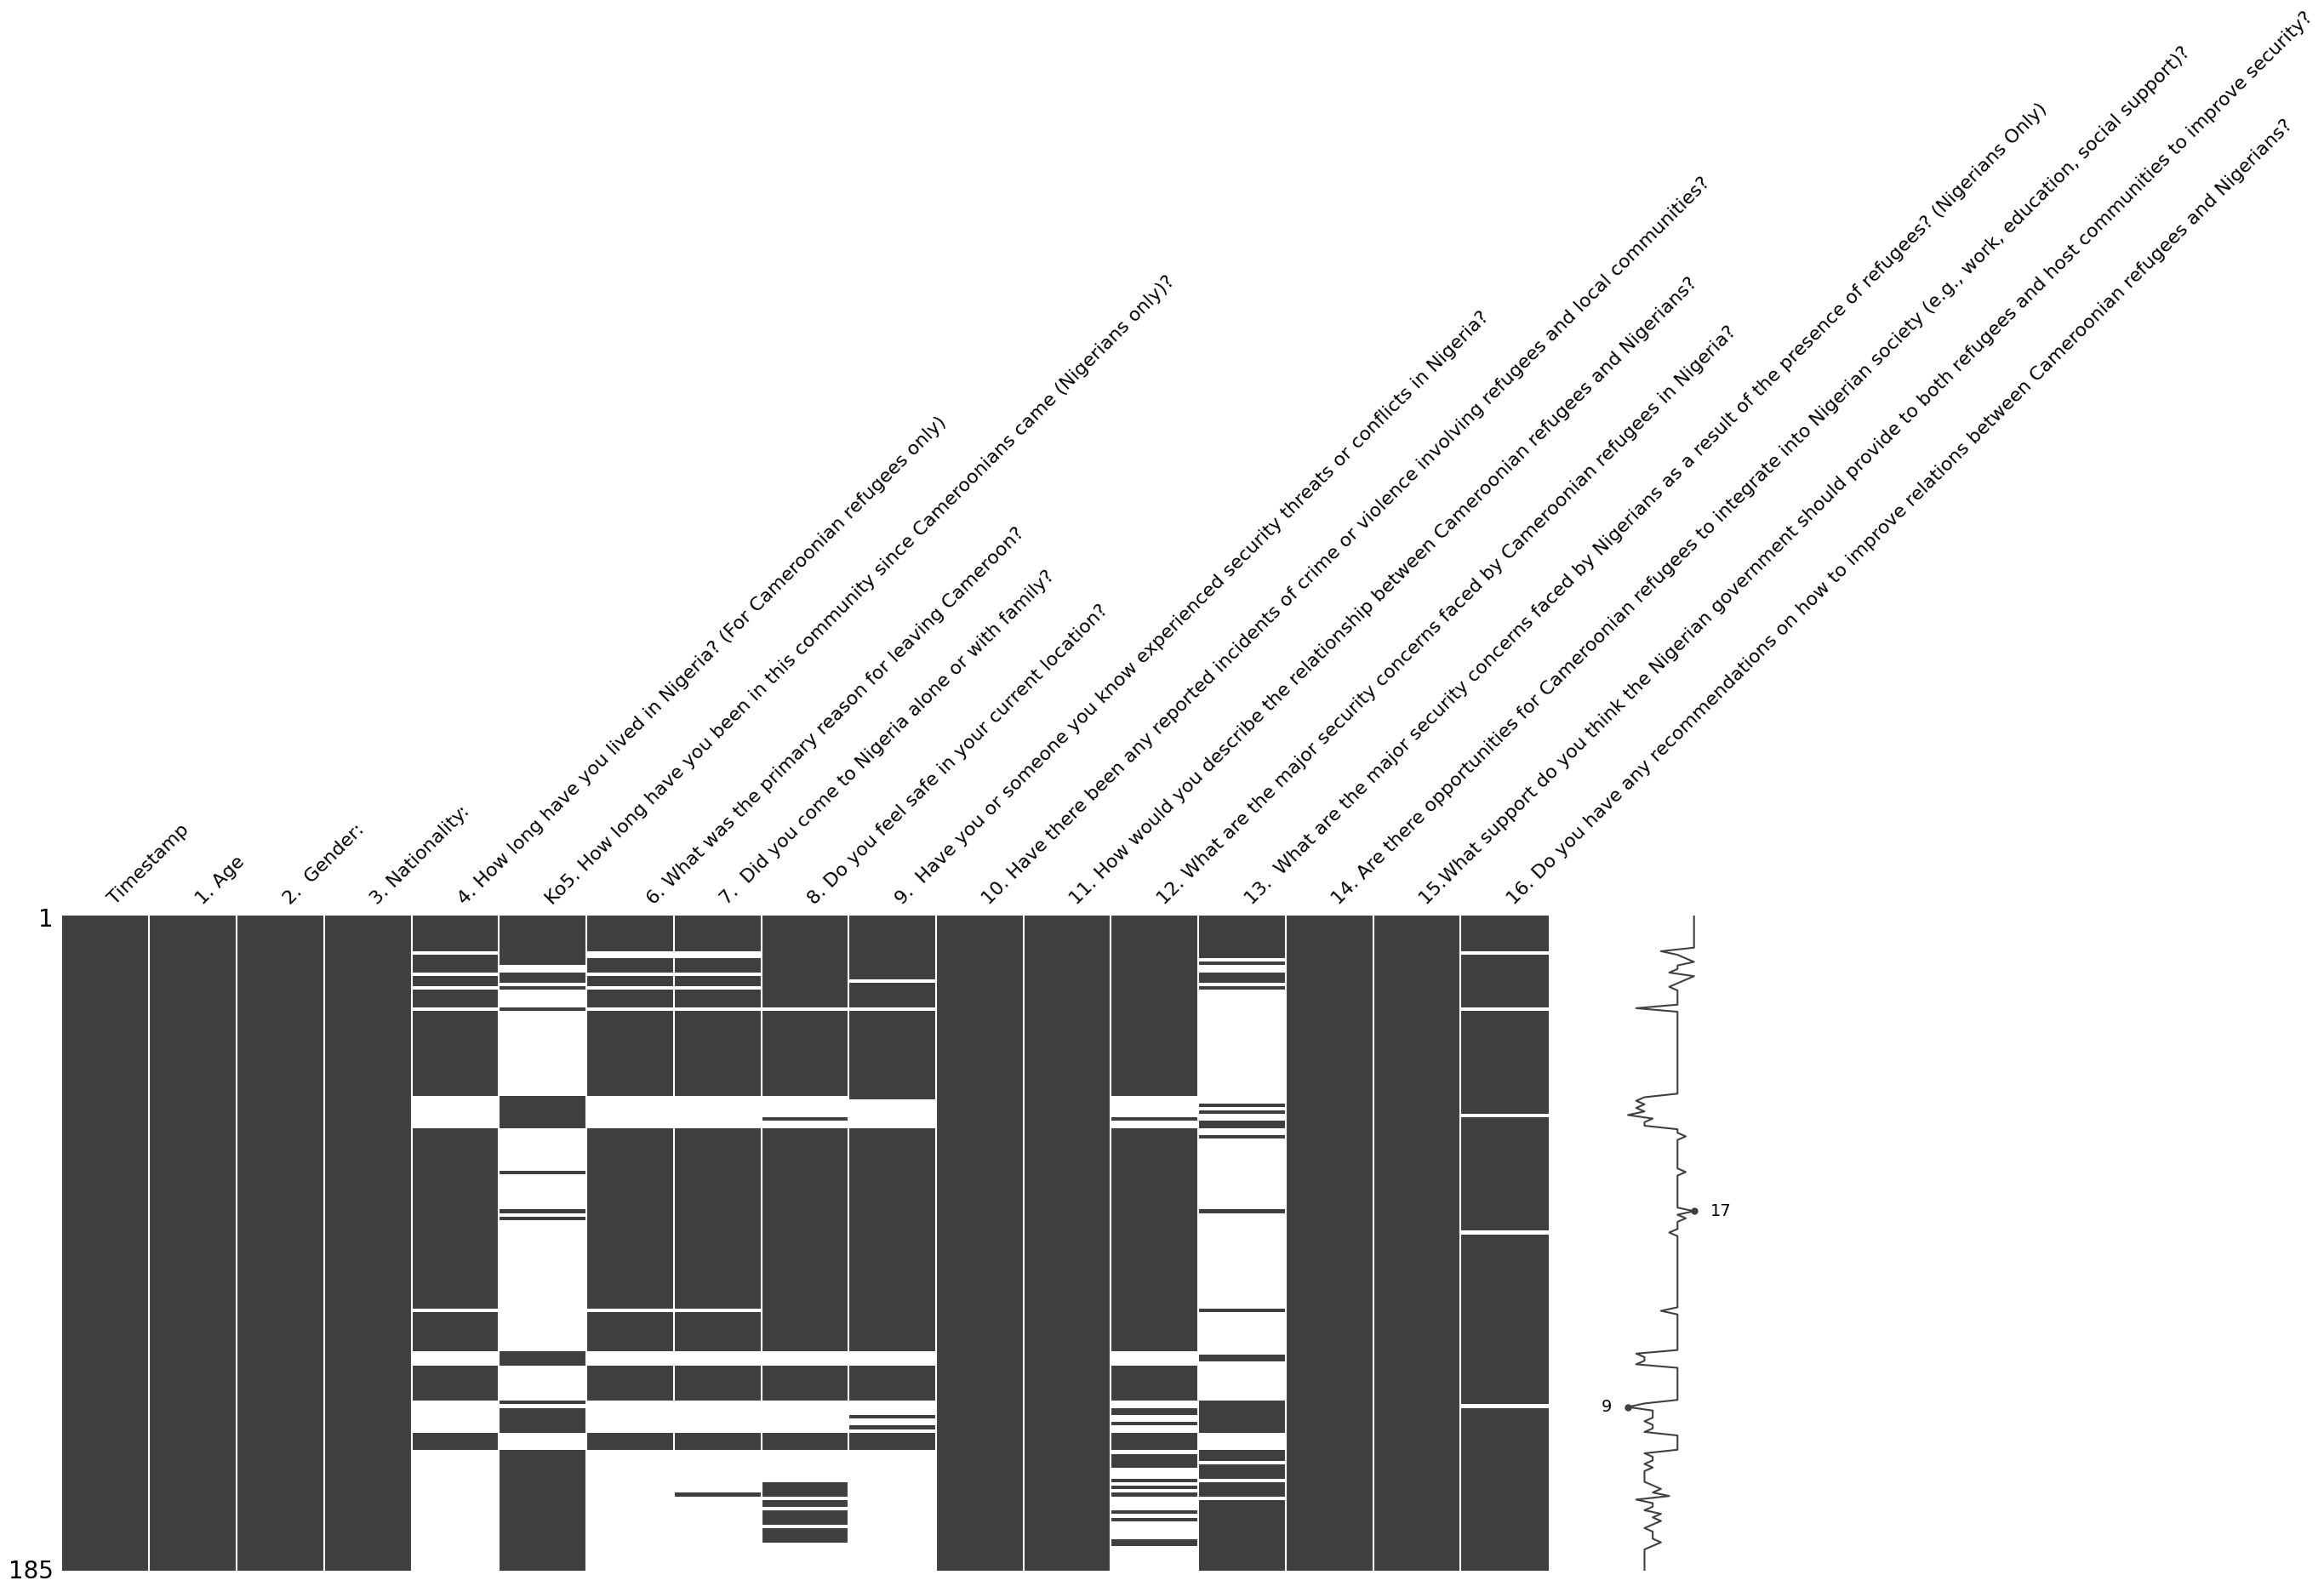

In [13]:
import missingno as msno

msno.matrix(df)

In [15]:
df["2.  Gender:"].value_counts().to_frame()

,count
2. Gender:,
A) Male,96
B) Female,89
